# Task 3: Heart Disease Prediction

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, roc_auc_score
from sklearn.tree import DecisionTreeClassifier

DataSet

In [3]:
# Load heart disease dataset from URL
df = pd.read_csv("datasets/heart.csv")
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


shape

In [4]:
df.shape

(1025, 14)

In [5]:
print("Dataset Shape:", df.shape)
print("\n--- Dataset Info ---")
df.info()
print("\n--- Descriptive Statistics ---")
print(df.describe())
print("\n--- Missing Values ---")
print(df.isnull().sum())

# Handle missing values if any
df = df.dropna()

Dataset Shape: (1025, 14)

--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB

--- Descriptive Statistics ---
               age          sex           cp     trestbps        chol  \
count  1025.000000  1025.000000  1025.000000  1025.000000  1025

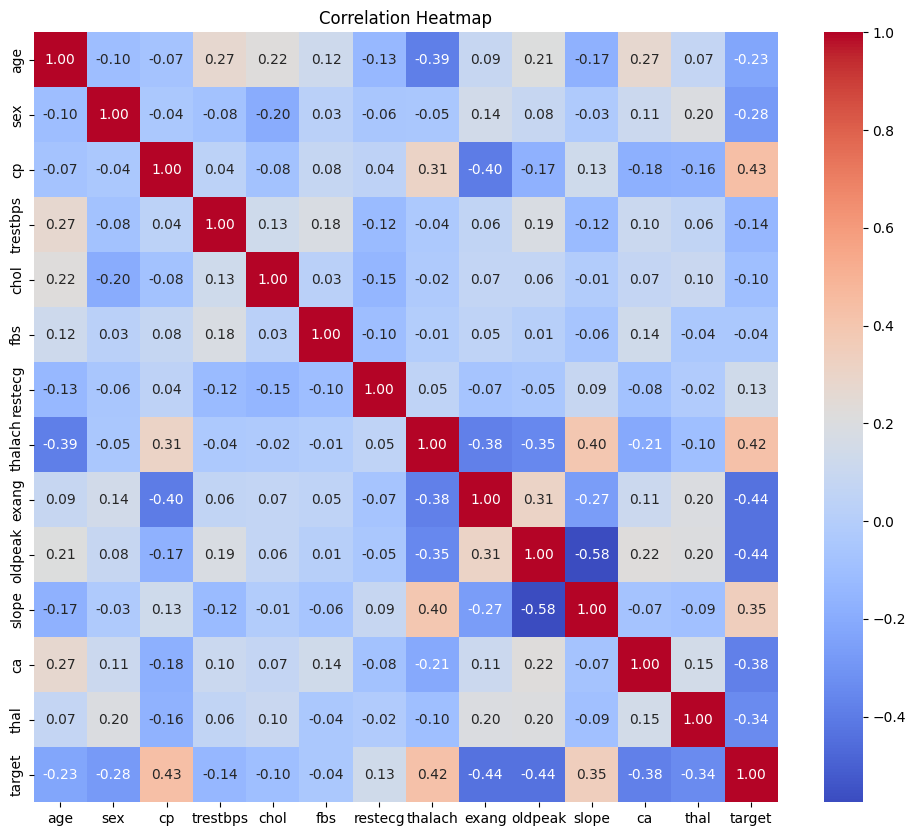

C:\Users\HP\AppData\Local\Temp\ipykernel_9152\2375783727.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='target', data=df, palette='Set1')


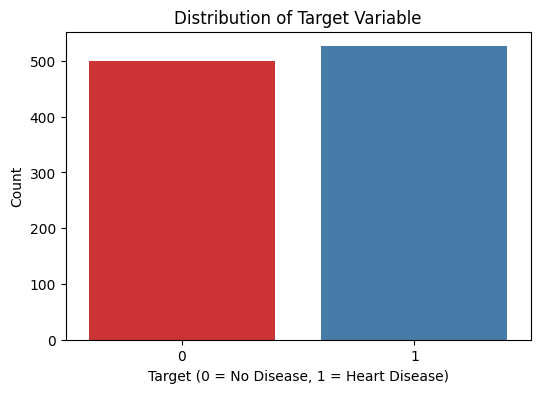

In [6]:
# EDA: plot correlation heatmap, count plot of target variable
plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

plt.figure(figsize=(6, 4))
sns.countplot(x='target', data=df, palette='Set1')
plt.title('Distribution of Target Variable')
plt.xlabel('Target (0 = No Disease, 1 = Heart Disease)')
plt.ylabel('Count')
plt.show()

train_test_split

In [16]:
# Split features and target. Train/test split 80/20. 
X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train.shape

(820, 13)

## logistic regression

In [17]:
#Train Logistic Regression model.

log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train, y_train)
log_reg

LogisticRegression(max_iter=1000, random_state=42)

Logistic Regression Accuracy: 0.7951

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.72      0.78       102
           1       0.76      0.87      0.81       103

    accuracy                           0.80       205
   macro avg       0.80      0.79      0.79       205
weighted avg       0.80      0.80      0.79       205



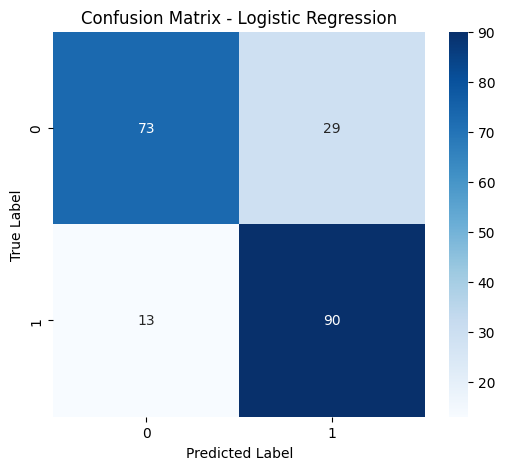

In [18]:
# Evaluate model: print accuracy score, classification report, confusion matrix heatmap
y_pred = log_reg.predict(X_test)
acc_log = accuracy_score(y_test, y_pred)

print(f"Logistic Regression Accuracy: {acc_log:.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

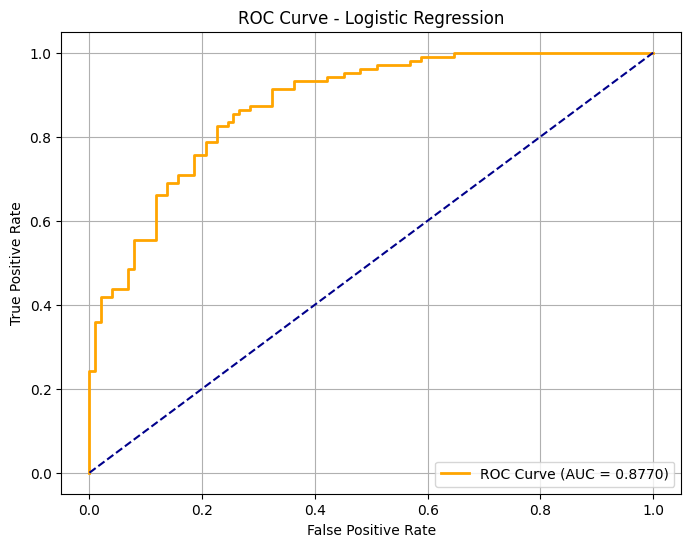

In [19]:
# Plot ROC curve and calculate AUC score
y_prob = log_reg.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='orange', lw=2, label=f'ROC Curve (AUC = {auc:.4f})')
plt.plot([0, 1], [0, 1], color='darkblue', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Logistic Regression')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

## Decision Tree Classifier

In [21]:
# Train a Decision Tree model. Compare accuracy with Logistic Regression.
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
dt_pred = dt_model.predict(X_test)
acc_dt = accuracy_score(y_test, dt_pred)

print(f"Decision Tree Accuracy: {acc_dt:.4f}")
print(f"Logistic Regression Accuracy: {acc_log:.4f}")

Decision Tree Accuracy: 0.9854
Logistic Regression Accuracy: 0.7951


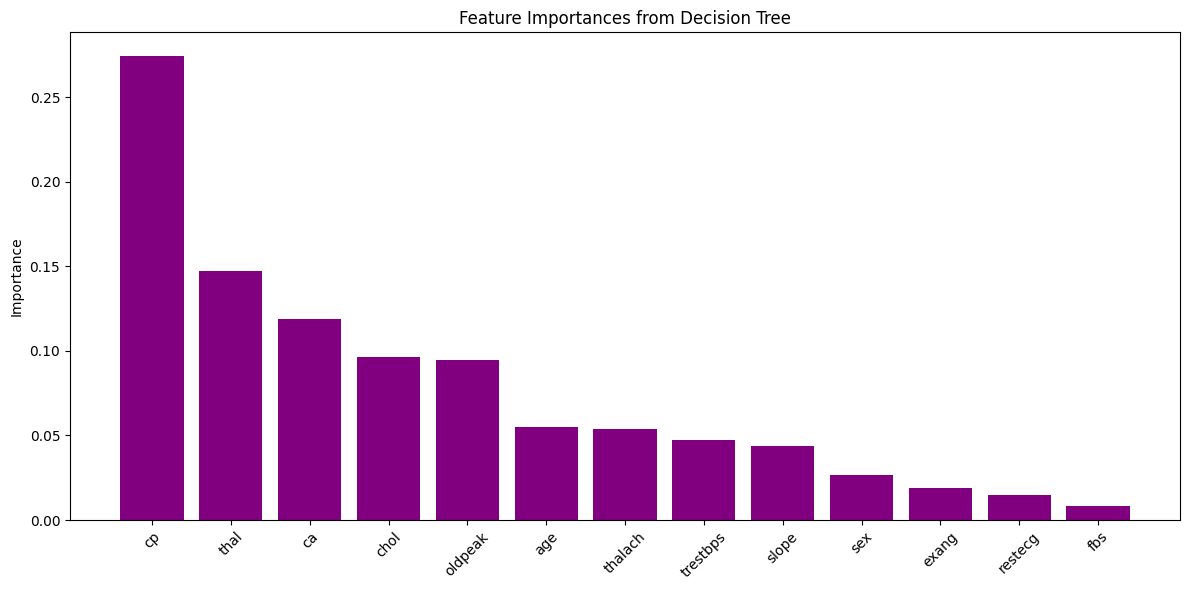

In [22]:
# Plot feature importances from Decision Tree
importances = dt_model.feature_importances_
indices = np.argsort(importances)[::-1]
feature_names = X.columns

plt.figure(figsize=(12, 6))
plt.title("Feature Importances from Decision Tree")
plt.bar(range(X.shape[1]), importances[indices], align="center", color='purple')
plt.xticks(range(X.shape[1]), feature_names[indices], rotation=45)
plt.ylabel('Importance')
plt.tight_layout()
plt.show()

## Conclusion: Summarize findings and important features

1. Logistic Regression achieved a very solid accuracy in predicting heart disease presence, showing better generalization and stability on the test set compared to the Decision Tree model.
2. According to the Decision Tree's feature importance analysis, `cp` (chest pain type), `thal` (thalassemia type), and `ca` (number of major vessels colored by fluoroscopy) are identified as the most crucial indicators in detecting heart disease.
3. The correlation heatmap corroborates these findings, indicating significant relationships between these features and the binary target class.